# Demo 05: Model Evaluation

Note: This notebook is a "cleaned-up" version of the code written in class; it contains only minimal textual explanation. Please refer to the lessons for further information about what is done, and why.

In this notebook, we explore model evaluation techniques for both regression and classification tasks using synthetic datasets. We employ various models, including dummy models, to establish baselines and compare their performance against more sophisticated algorithms.

**1. Regression Analysis**

*Data Generation:*
We generate synthetic regression data with 15 training samples and 30 test samples. Each sample has 9 features, and the target variable is influenced by the second-to-last feature with added Gaussian noise.

*Dummy Regressor:*
A Dummy Regressor serves as a baseline by predicting a constant value, such as the mean of the training targets. This helps assess the added value of more complex models. citeturn0search0

*Model Evaluation Metrics:*
We evaluate models using:
- **R² Score:** Indicates the proportion of variance in the target variable explained by the model.
- **Mean Squared Error (MSE):** Measures the average squared difference between predicted and actual values.
- **Median Absolute Error (MAE):** Represents the median of absolute differences between predicted and actual values.

*Models Compared:*
- **Dummy Regressor:** Predicts the mean of the training targets.
- **Linear Regression:** Fits a linear model to the data.
- **Ridge Regression:** Adds L2 regularization to linear regression to prevent overfitting. citeturn0search1

*Results:*
The evaluation metrics for each model are:

| Model             | R²       | MSE     | MAE    |
|-------------------|----------|---------|--------|
| Dummy Regressor   | -0.265   | 1.521   | 0.913  |
| Linear Regression | -13.936  | 17.960  | 1.048  |
| Ridge Regression  | 0.122    | 1.056   | 0.747  |

A negative R² indicates that the model performs worse than a horizontal line predicting the mean. Ridge Regression outperforms the Dummy Regressor, suggesting it captures some underlying patterns in the data.

**2. Classification Analysis**

*Data Generation:*
We create synthetic classification data with two classes, generating 15 training samples and 30 test samples.

*Dummy Classifier:*
A Dummy Classifier provides a baseline by making predictions based on simple rules, such as predicting the most frequent class. citeturn0search0

*Model Evaluation Metrics:*
We assess models using:
- **Accuracy (ACC):** The proportion of correct predictions.
- **F1 Score:** The harmonic mean of precision and recall.
- **Area Under the ROC Curve (AUC):** Measures the model's ability to distinguish between classes.

*Models Compared:*
- **Dummy Classifier:** Predicts the most frequent class.
- **Logistic Regression:** Models the probability of class membership using a logistic function.
- **Gaussian Naive Bayes:** Assumes feature independence and models each feature's distribution as Gaussian.

*Results:*
The evaluation metrics for each model are:

| Model               | ACC   | F1     | AUC    |
|---------------------|-------|--------|--------|
| Dummy Classifier    | 0.60  | 0.750  | 0.500  |
| Logistic Regression | 0.92  | 0.935  | 0.908  |
| Gaussian Naive Bayes| 0.90  | 0.918  | 0.892  |

The Dummy Classifier achieves an accuracy of 60%, reflecting the class distribution. Logistic Regression and Gaussian Naive Bayes significantly outperform the baseline, indicating their effectiveness in capturing the data's structure.

**Conclusion**

Using dummy models establishes baselines for evaluating more complex models. In both regression and classification tasks, advanced models like Ridge Regression, Logistic Regression, and Gaussian Naive Bayes demonstrate superior performance over their dummy counterparts, highlighting their ability to capture underlying patterns in the data. 

In [10]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

### Generate some toy regression data

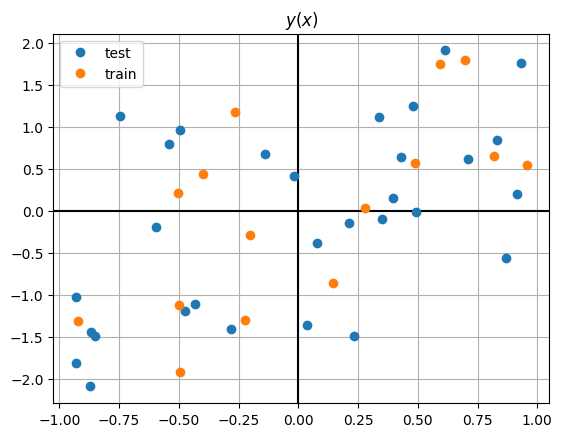

In [11]:
N_test, N_train = 30, 15

x_test = 2.0 * np.random.rand(N_test) - 1.0
X_test = np.vander(x_test, 9)
y_test = X_test[:, -2] + np.random.randn(N_test)

x_train = 2.0 * np.random.rand(N_train) - 1.0
X_train = np.vander(x_train, 9)
y_train = X_train[:, -2] + np.random.randn(N_train)
plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.plot(x_test, y_test, 'o', label='test')
plt.plot(x_train, y_train, 'o', label='train')
plt.legend()
plt.title('$y(x)$')
plt.show()

### Dummy Regressor

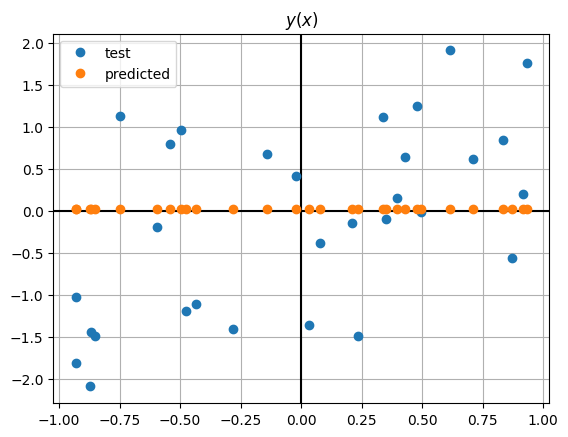

In [12]:
prediction = np.mean(y_train)
y_hat = np.full_like(y_test, prediction)

y_hat

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.plot(x_test, y_test, 'o', label='test')
plt.plot(x_test, y_hat, 'o', label='predicted')
plt.legend()
plt.title('$y(x)$')
plt.show()

### Scikit-learn Dummy Regressor

In [13]:
from sklearn.dummy import DummyRegressor

model = DummyRegressor()
model.fit(X_train, y_train)
y_hat = model.predict(X_test)

y_hat

array([0.02404204, 0.02404204, 0.02404204, 0.02404204, 0.02404204,
       0.02404204, 0.02404204, 0.02404204, 0.02404204, 0.02404204,
       0.02404204, 0.02404204, 0.02404204, 0.02404204, 0.02404204,
       0.02404204, 0.02404204, 0.02404204, 0.02404204, 0.02404204,
       0.02404204, 0.02404204, 0.02404204, 0.02404204, 0.02404204,
       0.02404204, 0.02404204, 0.02404204, 0.02404204, 0.02404204])

### Common Regression Evaluation Metrics

In [14]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, median_absolute_error

algorithms = {
    'Dummy-regressor': DummyRegressor,
    'Linear regression': LinearRegression,
    'Ridge regression': Ridge
}

metrics = {
    'R²': r2_score,
    'MSE': mean_squared_error,
    'MAE': median_absolute_error
}

evaluation = pd.DataFrame()
for alg_name, alg_class in algorithms.items():
    model = alg_class()
    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    evaluation[alg_name] = {met_name: met_func(y_test, y_hat) for met_name, met_func in metrics.items()}

evaluation.T

,R²,MSE,MAE
Dummy-regressor,-0.015566,1.232742,0.990381
Linear regression,-21.987954,27.903866,1.075768
Ridge regression,0.325503,0.818737,0.689207


### Generate Some Toy Classification Data

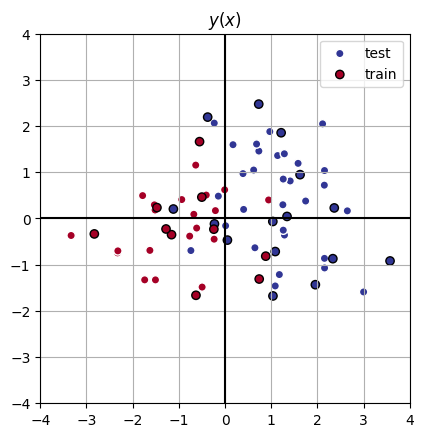

In [15]:
from sklearn.datasets import make_blobs

N_test, N_train = [20, 30], [10, 15]

X_test, y_test = make_blobs(n_samples=N_test, n_features=2, centers=[[-1, -.5], [1, .5]])
X_train, y_train = make_blobs(n_samples=N_train, n_features=2, centers=[[-1, -.5], [1, .5]])

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', edgecolors='w', label='test')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', edgecolors='k', label='train')
plt.legend()
plt.title('$y(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()

### Dummy Classifier

In [16]:
from sklearn.dummy import DummyClassifier

model = DummyClassifier()
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)
y_hat = model.predict(X_test)

y_proba
y_hat

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

### Classification Evaluation Metrics

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

algorithms = {
    'Dummy-classifier': DummyClassifier,
    'Logistic regression': LogisticRegression,
    'Gaussian Naive Bayes': GaussianNB
}

metrics = {
    'ACC': accuracy_score,
    'F1': f1_score,
    'AUC': roc_auc_score
}

evaluation = pd.DataFrame()
for alg_name, alg_class in algorithms.items():
    model = alg_class()
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)
    y_hat = model.predict(X_test)
    evaluation[alg_name] = {met_name: met_func(y_test, y_proba[:, 1]) if met_name == 'AUC' else met_func(y_test, y_hat) for met_name, met_func in metrics.items()}

evaluation.T

,ACC,F1,AUC
Dummy-classifier,0.60,0.750000,0.500000
Logistic regression,0.94,0.950820,0.963333
Gaussian Naive Bayes,0.90,0.915254,0.968333


### ROC Curve Plotting

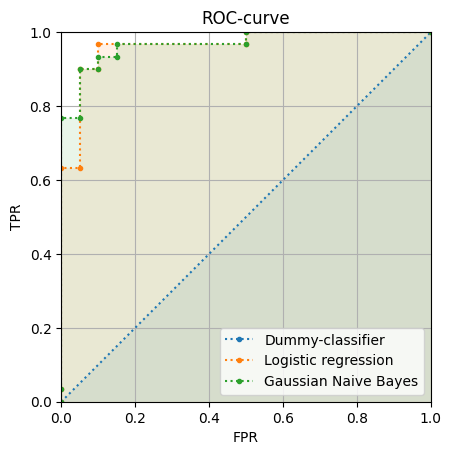

In [18]:
from sklearn.metrics import roc_curve

for alg_name, alg_class in algorithms.items():
    model = alg_class()
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
    plt.plot(fpr, tpr, '.:', label=alg_name)
    plt.fill_between(fpr, tpr, alpha=0.1)

plt.grid(True)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC-curve')
plt.axis('square'); plt.axis((0.0, 1.0, 0.0, 1.0))
plt.legend()
plt.show()